In [1]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("../Data/sample_-_superstore.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/sample_-_superstore.xlsx'

In [3]:
import os

print(os.listdir("../Data"))

['sample_-_superstore.csv']


In [4]:
df = pd.read_csv("../Data/sample_-_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01-03-2023,01-07-2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01-04-2023,01-08-2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01-04-2023,01-08-2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01-04-2023,01-08-2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01-05-2023,01-12-2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


# Superstore Sales Analysis

## Project Objective
Analyze sales, profit, discounts, customer behavior, and product performance to identify business insights and improve decision-making.

### Tools Used
- Python
- Pandas
- NumPy
- Jupyter Notebook

### Dataset
Superstore Sales Dataset

In [5]:
df.shape

(10194, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date columns converted successfully!")

ValueError: time data "13-07-2023" doesn't match format "%m-%d-%Y", at position 27. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Date columns converted successfully!")

ValueError: time data "01/13/2023" doesn't match format "%d-%m-%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [10]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2023-03-01,01-07-2023
1,2023-04-01,01-08-2023
2,2023-04-01,01-08-2023
3,2023-04-01,01-08-2023
4,2023-05-01,01-12-2023


In [11]:
df['Order Date'].head(20)

0    2023-03-01
1    2023-04-01
2    2023-04-01
3    2023-04-01
4    2023-05-01
5    2023-06-01
6    2023-06-01
7    2023-06-01
8    2023-06-01
9    2023-06-01
10   2023-06-01
11   2023-06-01
12   2023-06-01
13   2023-06-01
14   2023-07-01
15   2023-07-01
16   2023-07-02
17   2023-07-03
18   2023-07-04
19   2023-07-05
Name: Order Date, dtype: datetime64[ns]

In [12]:
df['Ship Date'].head(20)

0     01-07-2023
1     01-08-2023
2     01-08-2023
3     01-08-2023
4     01-12-2023
5     01-10-2023
6     01-10-2023
7     01-07-2023
8     01-10-2023
9     01-10-2023
10    01-10-2023
11    01-08-2023
12    01-10-2023
13    01-10-2023
14    01-12-2023
15    01-12-2023
16    01/13/2023
17    01/13/2023
18    01/15/2023
19    01/15/2023
Name: Ship Date, dtype: object

In [13]:
df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='mixed'
)

print("Ship Date converted successfully!")

Ship Date converted successfully!


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [1]:
df.duplicated().sum()

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("../Data/sample_-_superstore.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.duplicated().sum()

0

In [4]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
avg_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Profit Margin:", round(profit_margin, 2), "%")
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2326534.3543
Total Profit: 292296.81460000004
Profit Margin: 12.56 %
Total Orders: 5111
Average Order Value: 455.2


In [5]:
sales_by_category = df.groupby('Category')['Sales'].sum()

sales_by_category

Category
Furniture          754747.7613
Office Supplies    731893.3140
Technology         839893.2790
Name: Sales, dtype: float64

In [6]:
profit_by_category = df.groupby('Category')['Profit'].sum()

profit_by_category

Category
Furniture           19729.9956
Office Supplies    126023.4434
Technology         146543.3756
Name: Profit, dtype: float64

In [7]:
discount_by_category = df.groupby('Category')['Discount'].mean()

discount_by_category

Category
Furniture          0.172962
Office Supplies    0.156348
Technology         0.131475
Name: Discount, dtype: float64

In [8]:
(discount_by_category * 100).round(2)

Category
Furniture          17.30
Office Supplies    15.63
Technology         13.15
Name: Discount, dtype: float64

In [9]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

sales_by_category

Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64

In [10]:
sales_percentage = (
    df.groupby('Category')['Sales']
    .sum()
    / df['Sales'].sum()
    * 100
).round(2)

sales_percentage

Category
Furniture          32.44
Office Supplies    31.46
Technology         36.10
Name: Sales, dtype: float64

In [11]:
profit_percentage = (
    df.groupby('Category')['Profit']
    .sum()
    / df['Profit'].sum()
    * 100
).round(2)

print(profit_percentage.astype(str) + '%')

Category
Furniture           6.75%
Office Supplies    43.11%
Technology         50.14%
Name: Profit, dtype: object


In [12]:
discount_percentage = (
    df.groupby('Category')['Discount']
    .mean()
    * 100
).round(2)

print(discount_percentage.astype(str) + '%')

Category
Furniture           17.3%
Office Supplies    15.63%
Technology         13.15%
Name: Discount, dtype: object


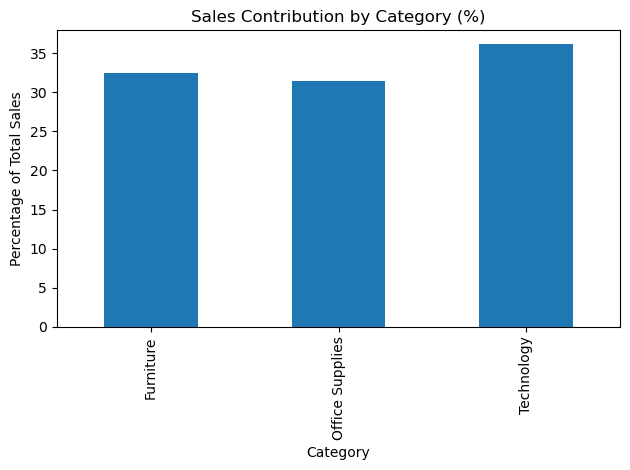

In [13]:
import matplotlib.pyplot as plt

sales_percentage.plot(
    kind='bar'
)

plt.title('Sales Contribution by Category (%)')
plt.ylabel('Percentage of Total Sales')
plt.xlabel('Category')

plt.tight_layout()
plt.show()

In [15]:
df.to_csv("../Data/cleaned_superstore.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [16]:
import os
os.listdir("../Data")

['cleaned_superstore.csv', 'sample_-_superstore.csv']